In [1]:
import os
from pathlib import Path

import numpy as np
import tensorflow as tf
import tensorflow_probability as tfp
from tqdm.notebook import tqdm

tf.config.experimental.enable_tensor_float_32_execution(False)
tf.keras.backend.set_floatx("float32")

tfd = tfp.distributions
tfb = tfp.bijectors

In [2]:
from modulars import (
    load_config,
    save_to_csv,
    load_from_csv,
    find_best_params,
    load_best_multid_reference,
    apply_traj_transform_simplex,
    iterated_sigmoid_centered_forward,
    build_summary_runs_from_scale_results,
)
from modulars.tfp_rr_test import tfp_run_restart_simplex
from modulars.distributions import gen_multinomial_data_shared, lda_posterior_shared_theta
from modulars.plot_rr import (
    plot_simplex_dims,
    plot_dirichlet_marginals_few_restarts,
    plot_dirichlet_mean_band_rrs,
    plot_dirichlet_simplex_pdf_zoom,
)

In [17]:
config_file = "dirichlet_config.json"
config = load_config(config_file)

theta_like = np.array(config["theta_like"], dtype=np.float32)
alpha_prior = np.array(config["alpha_prior"], dtype=np.float32)
n_cats = config["n_cats"]
N = config["N"]
total_count = config["total_count"]
max_iters = 100_000
n_restarts = 20
shared = config.get("shared", True)
seed = config.get("seed", 15)
results_dir = Path("results")

n_vec = np.full(N, total_count, dtype=int)

if shared:
    obs_counts = gen_multinomial_data_shared(
        theta_like, N, total_count, SEED=seed
    )
    true_post = lda_posterior_shared_theta(obs_counts, total_count, alpha_prior)
else:
    raise NotImplementedError("we only handle the shared-theta case here")


In [18]:
best_mean, best_cov, best_std = load_best_multid_reference(
    config,
    fallback_mean=true_post["mean_post"],
    fallback_cov=np.diag(np.square(true_post["std_post"])),
)

best_mean, best_cov, best_std

(array([0.40524086, 0.29408492, 0.30067422]),
 array([[ 0.00048565, -0.00024073, -0.00024492],
        [-0.00024073,  0.00041736, -0.00017663],
        [-0.00024492, -0.00017663,  0.00042156]]),
 array([0.02203747, 0.02042938, 0.02053184]))

In [5]:
# convert into tensors for tf to work
obs_counts_tf  = tf.constant(obs_counts, dtype=tf.float32)           # [N, K]
total_counts_per_cat = tf.reduce_sum(obs_counts_tf, axis=0)  
alpha_prior_tf = tf.constant(alpha_prior, dtype=tf.float32)

def conditioned_log_prob_fn(theta):
        prior_log_prob = tfd.Dirichlet(alpha_prior_tf).log_prob(theta)  

        # Likelihood term: sum_k (sum_n x_{n,k}) * log theta_k
        # (Dropping the multinomial combinatorial constants — no theta dependence.)
        ll = tf.reduce_sum(total_counts_per_cat * tf.math.log(theta), axis=-1)
        out = prior_log_prob + ll
        return out

In [6]:
results = []
bij = tfb.IteratedSigmoidCentered()
for rr_seed in tqdm(range(n_restarts)):
    result = tfp_run_restart_simplex(
        seed + rr_seed * 100,
        n_cats,
        conditioned_log_prob_fn,
        bij,
        n_iters=max_iters,
    )
    results.append(result)

save_to_csv(results_dir / "tfp_raw_restarts.csv", results)

  0%|          | 0/20 [00:00<?, ?it/s]

2026-04-20 22:45:37.265123: W tensorflow/compiler/tf2xla/kernels/random_ops.cc:108] Warning: Using tf.random.uniform with XLA compilation will ignore seeds; consider using tf.random.stateless_uniform instead if reproducible behavior is desired. fit_surrogate_posterior/sanitize_seed/seed
I0000 00:00:1776739537.584259 18216956 device_compiler.h:196] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


In [7]:
loaded_results = load_from_csv(results_dir / "tfp_raw_restarts.csv")
single_means, single_stds, multi_means, multi_stds = apply_traj_transform_simplex(
    loaded_results,
    n_cats=n_cats,
    forward_fn=iterated_sigmoid_centered_forward,
    n_samples=50_000,
    seed=1,
)
summary_runs = build_summary_runs_from_scale_results(
    loaded_results,
    n_cats=n_cats,
    forward_fn=iterated_sigmoid_centered_forward,
    which="multi",
    n_samples=50_000,
    seed=seed,
)

save_to_csv(results_dir / "tfp_summary_restarts.csv", summary_runs)

local_best = find_best_params(
    [results_dir / "tfp_summary_restarts.csv"],
    alpha_prior=alpha_prior,
    obs_counts=obs_counts,
    grad_samps=100,
    seed=seed,
)




  0%|          | 0/20 [00:00<?, ?it/s]

18.329357
18.318302
18.320862
18.339931
18.335737
18.313227
18.323484
18.344875
18.337805
18.317087
18.32169
18.34391
18.334135
18.33811
18.316133
18.338636
18.32716
18.3445
18.315786
18.341387


In [8]:
save_to_csv(
    results_dir / "tfp_processed_restarts.csv",
    [(single_means, single_stds, multi_means, multi_stds)],
)


# loading after


In [9]:
loaded_processed = load_from_csv(results_dir / "tfp_processed_restarts.csv")[0]
single_means, single_stds, multi_means, multi_stds = loaded_processed


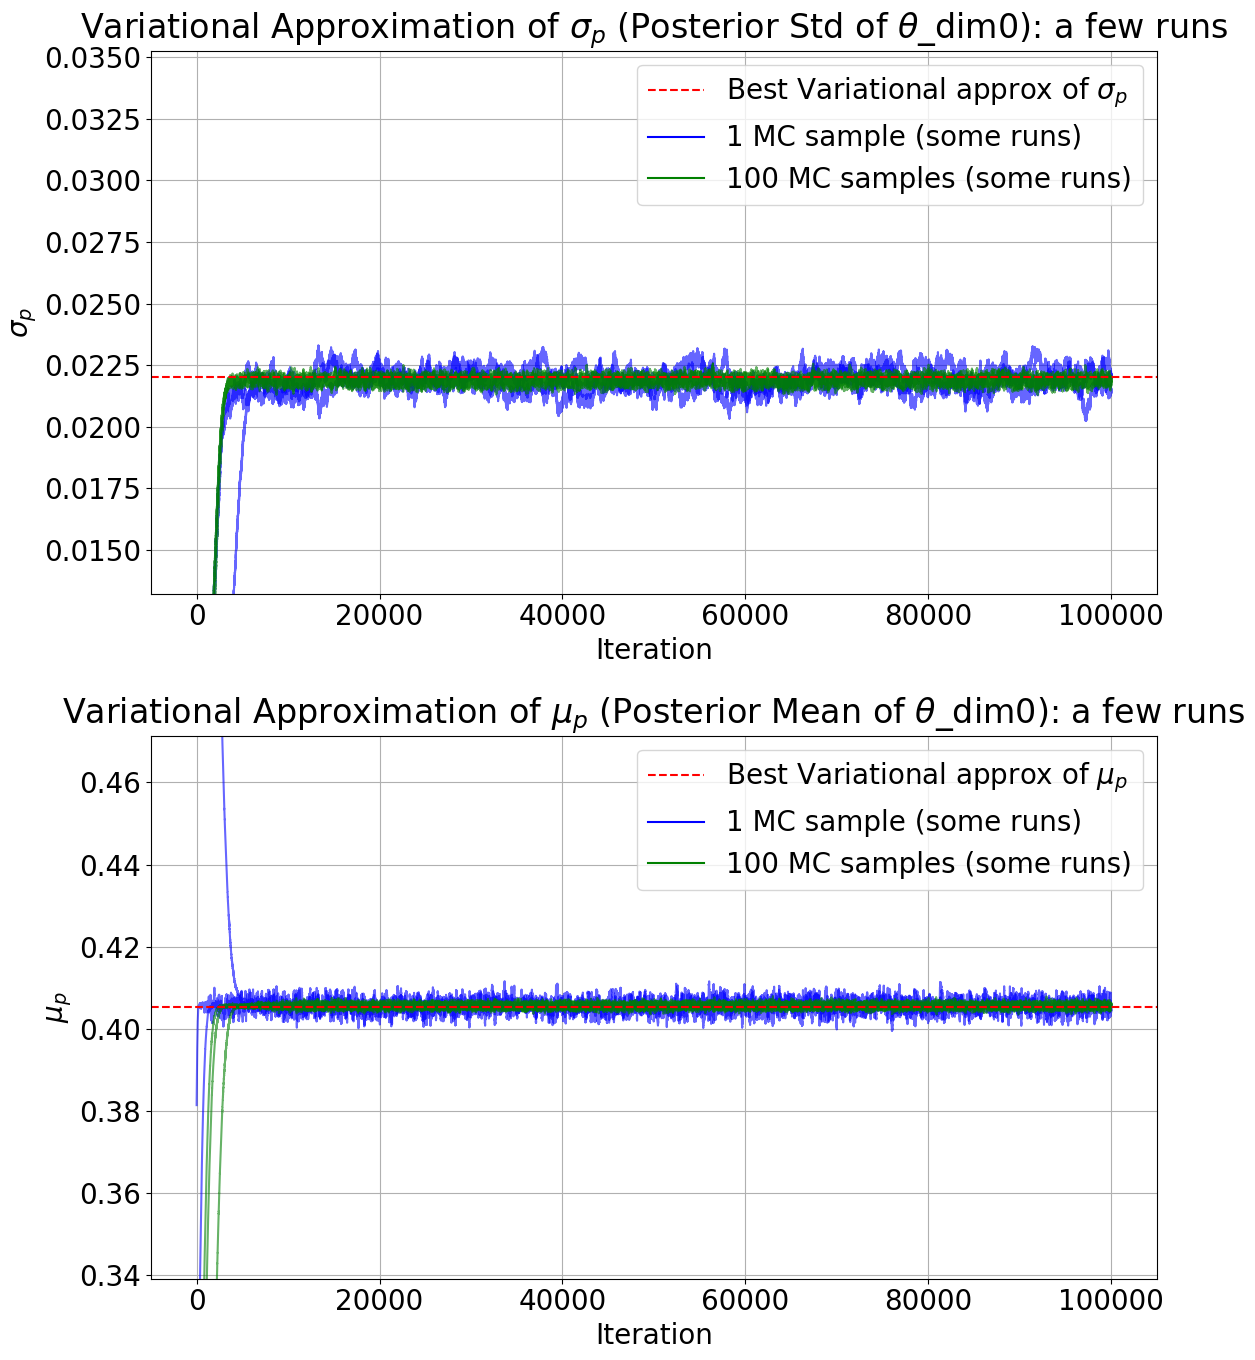

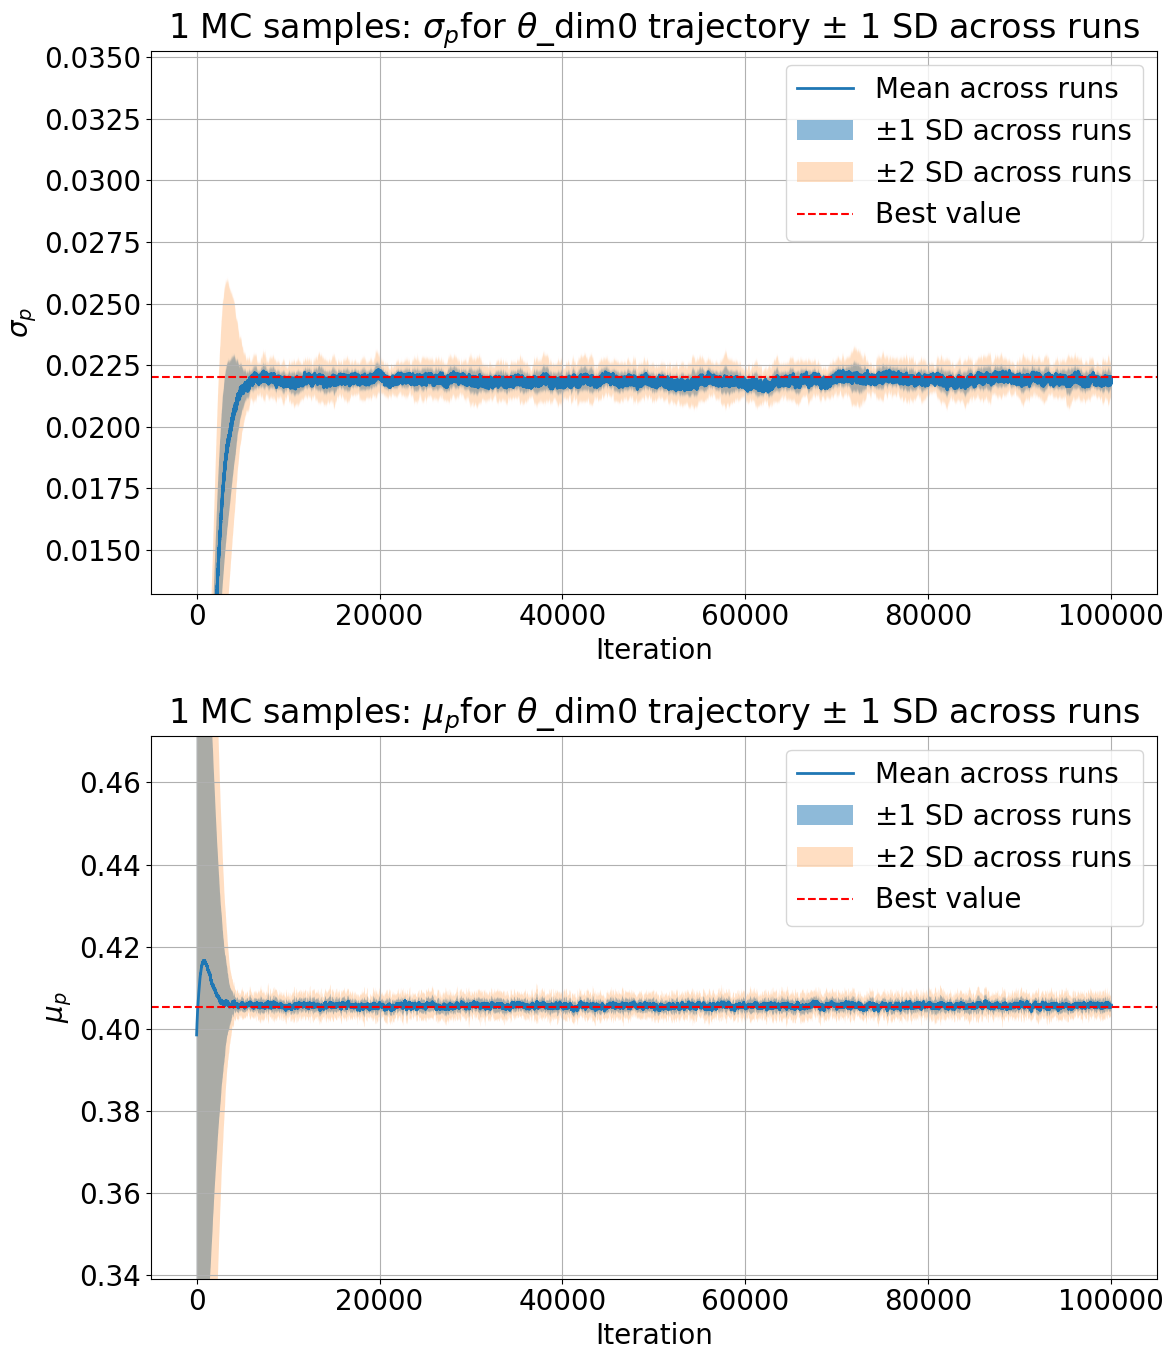

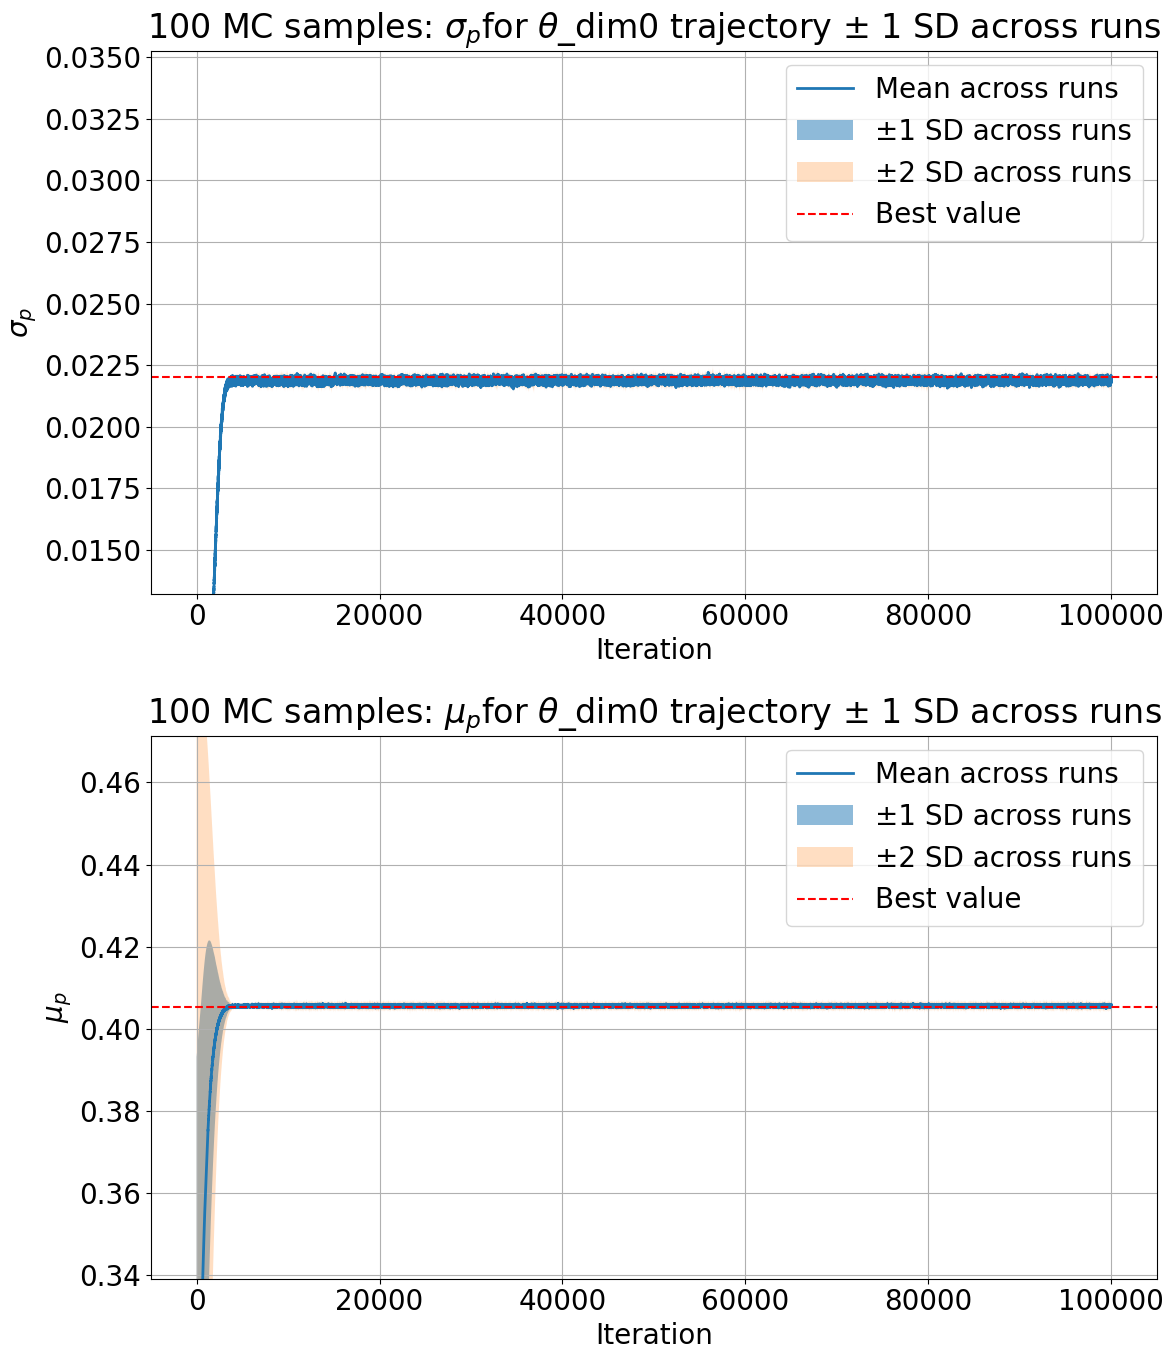

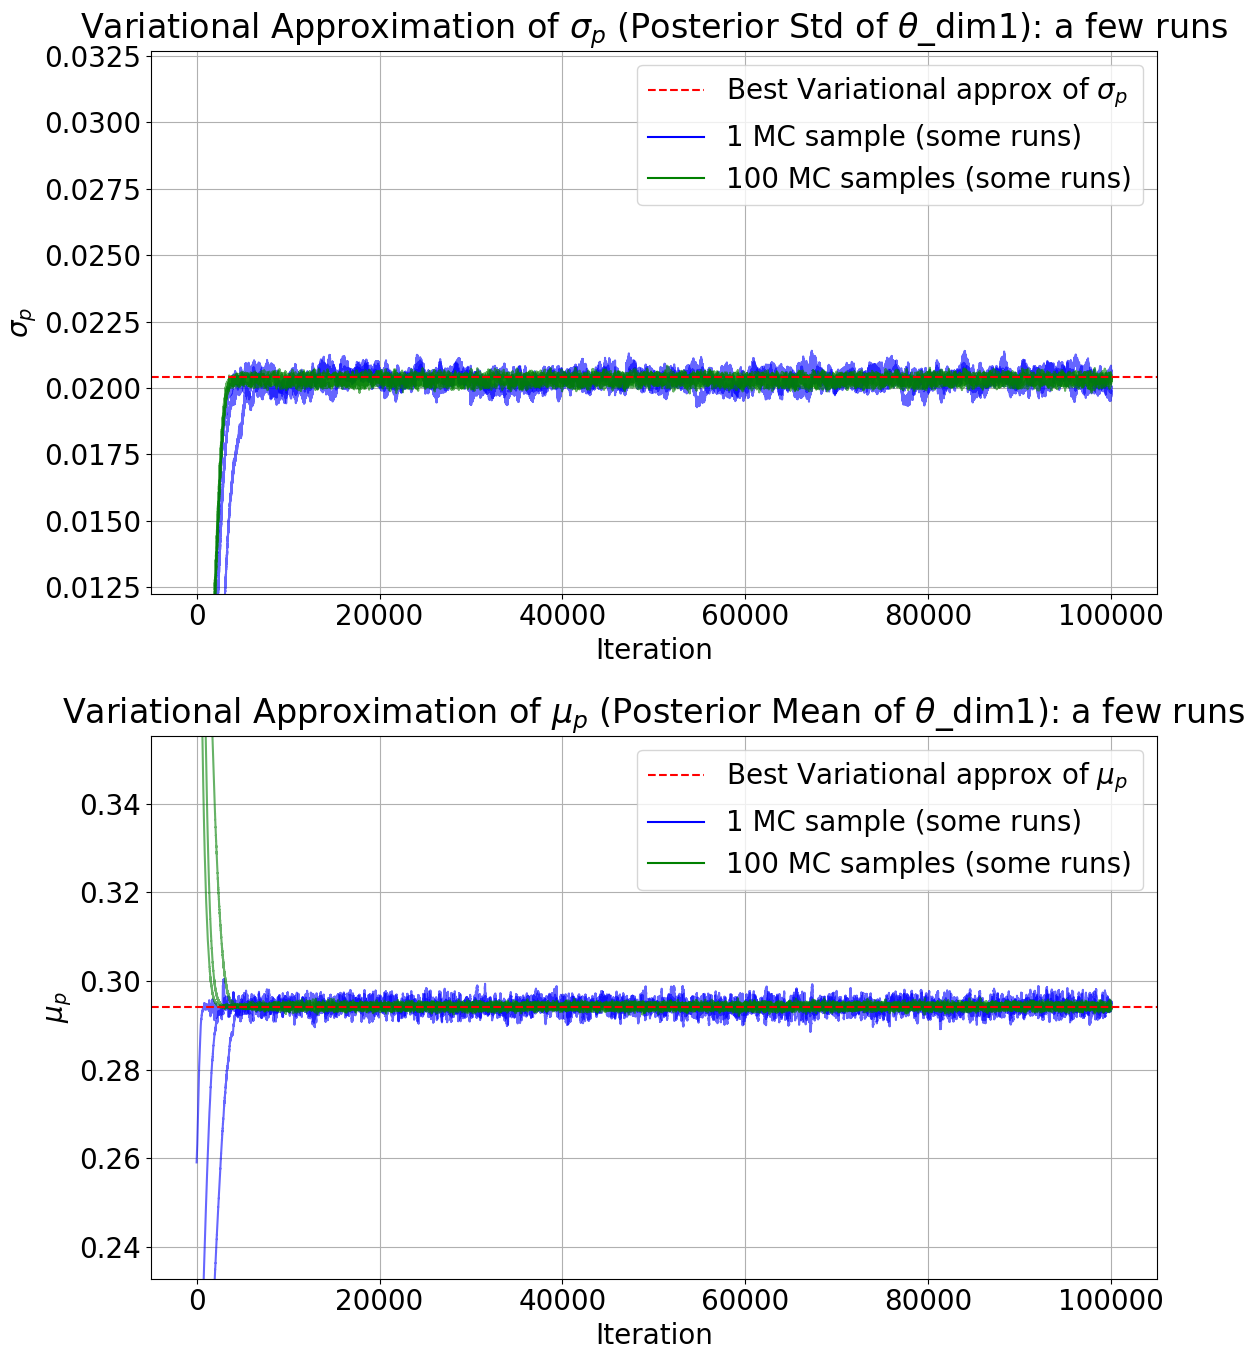

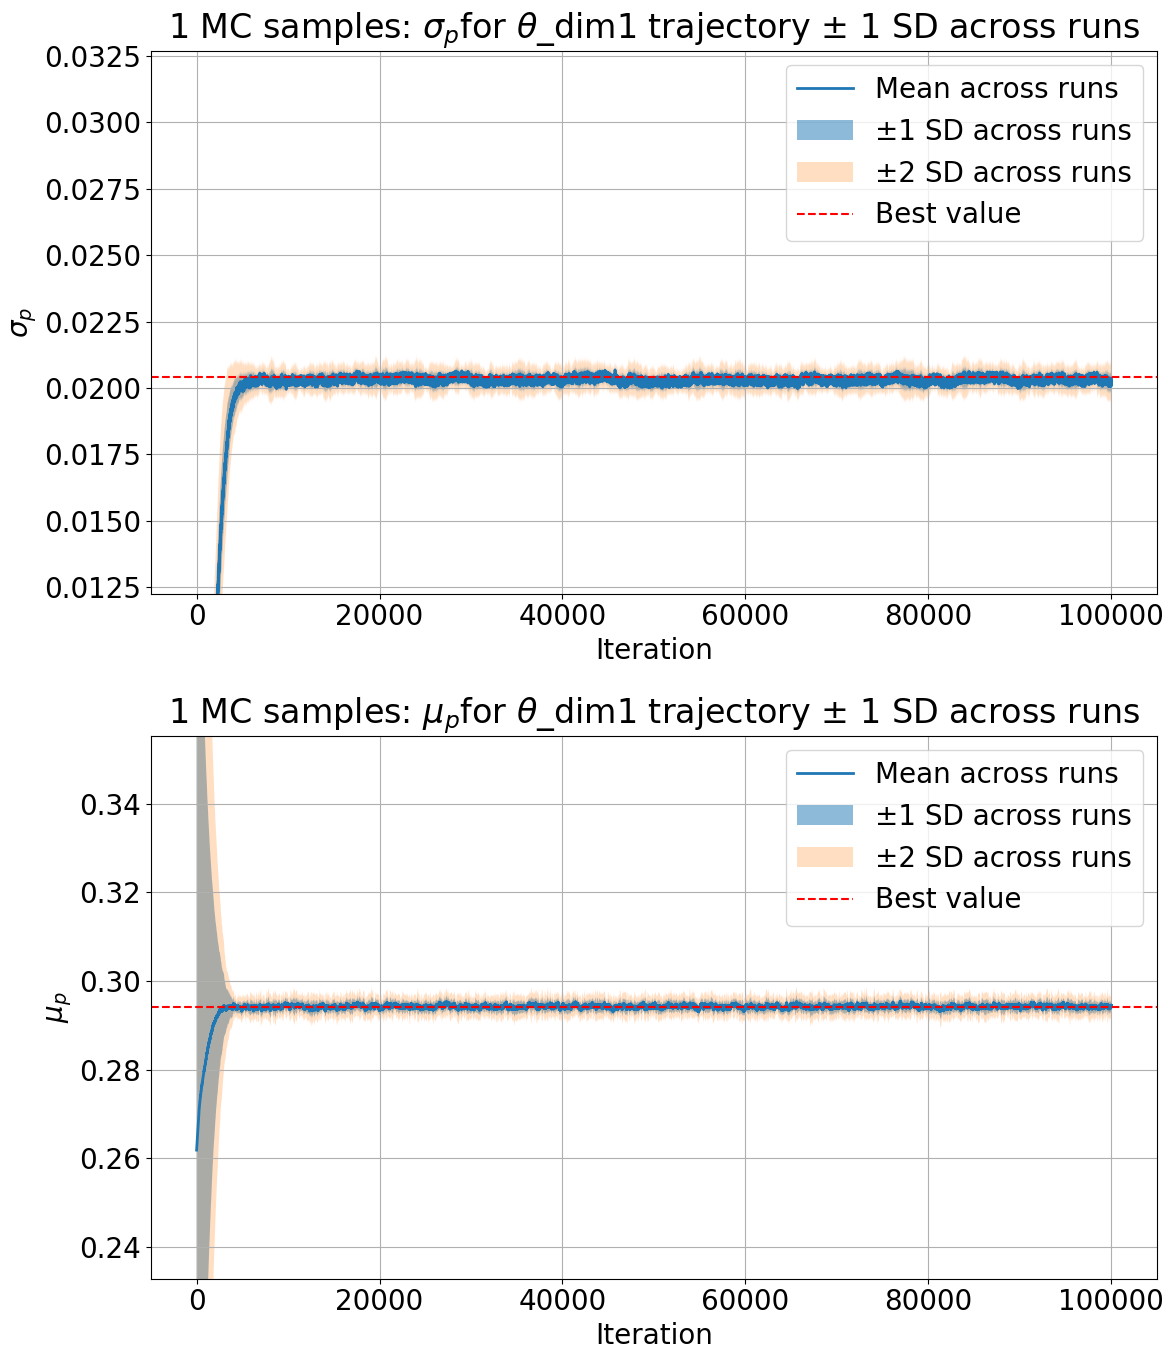

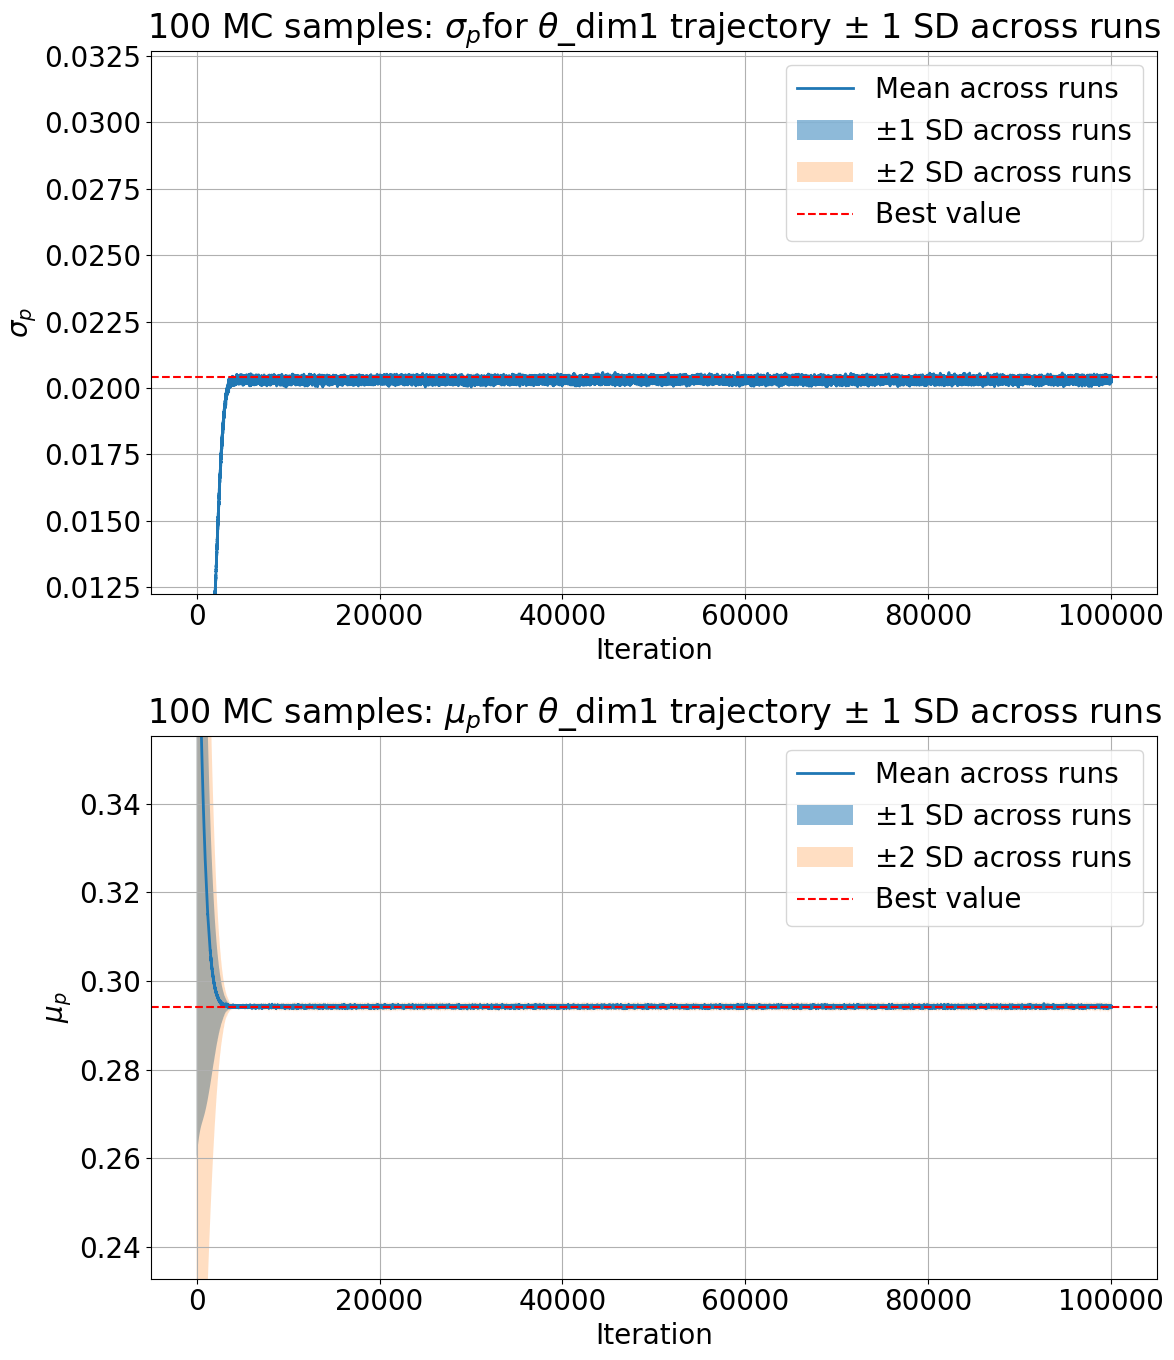

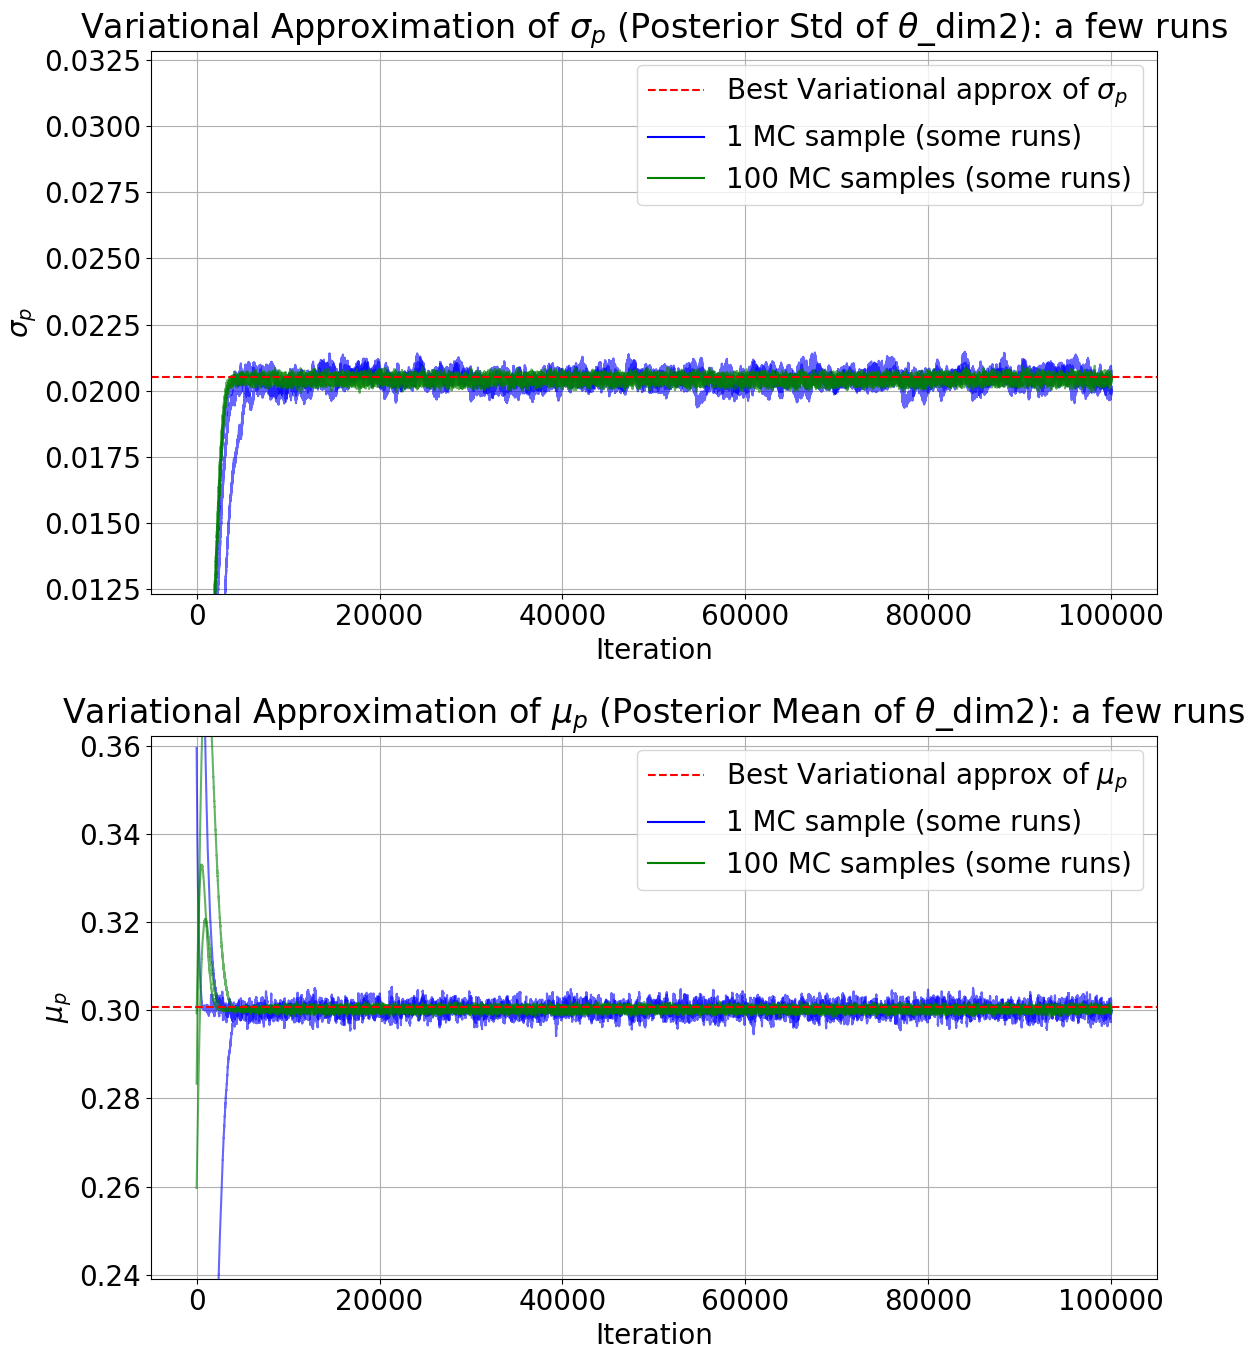

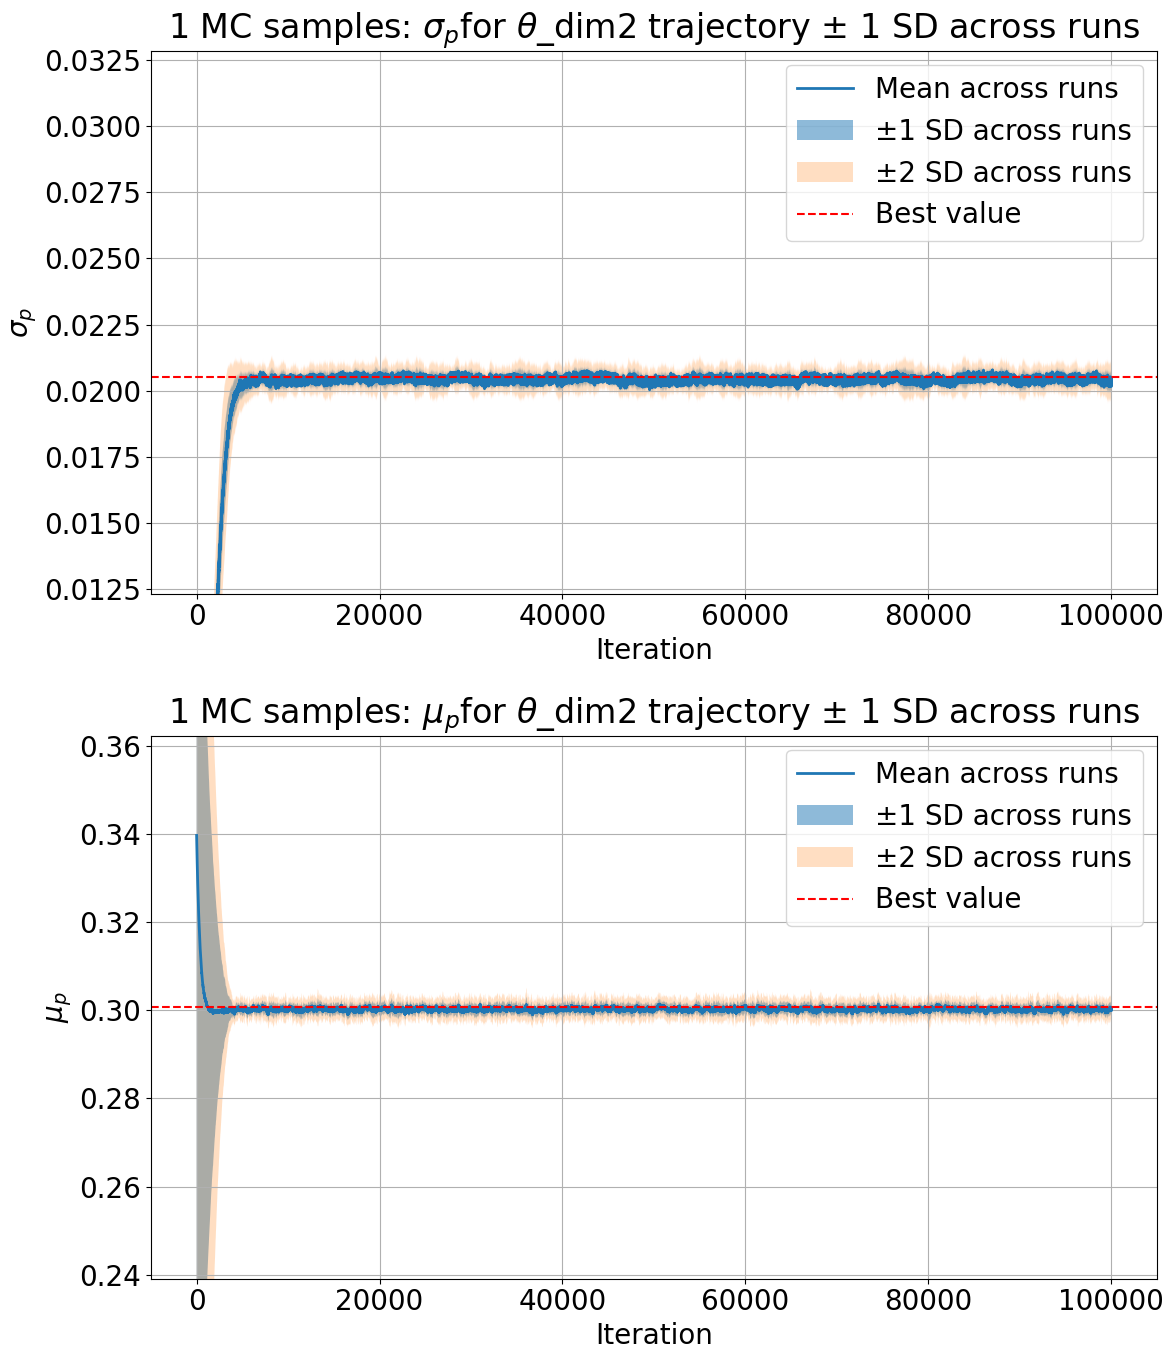

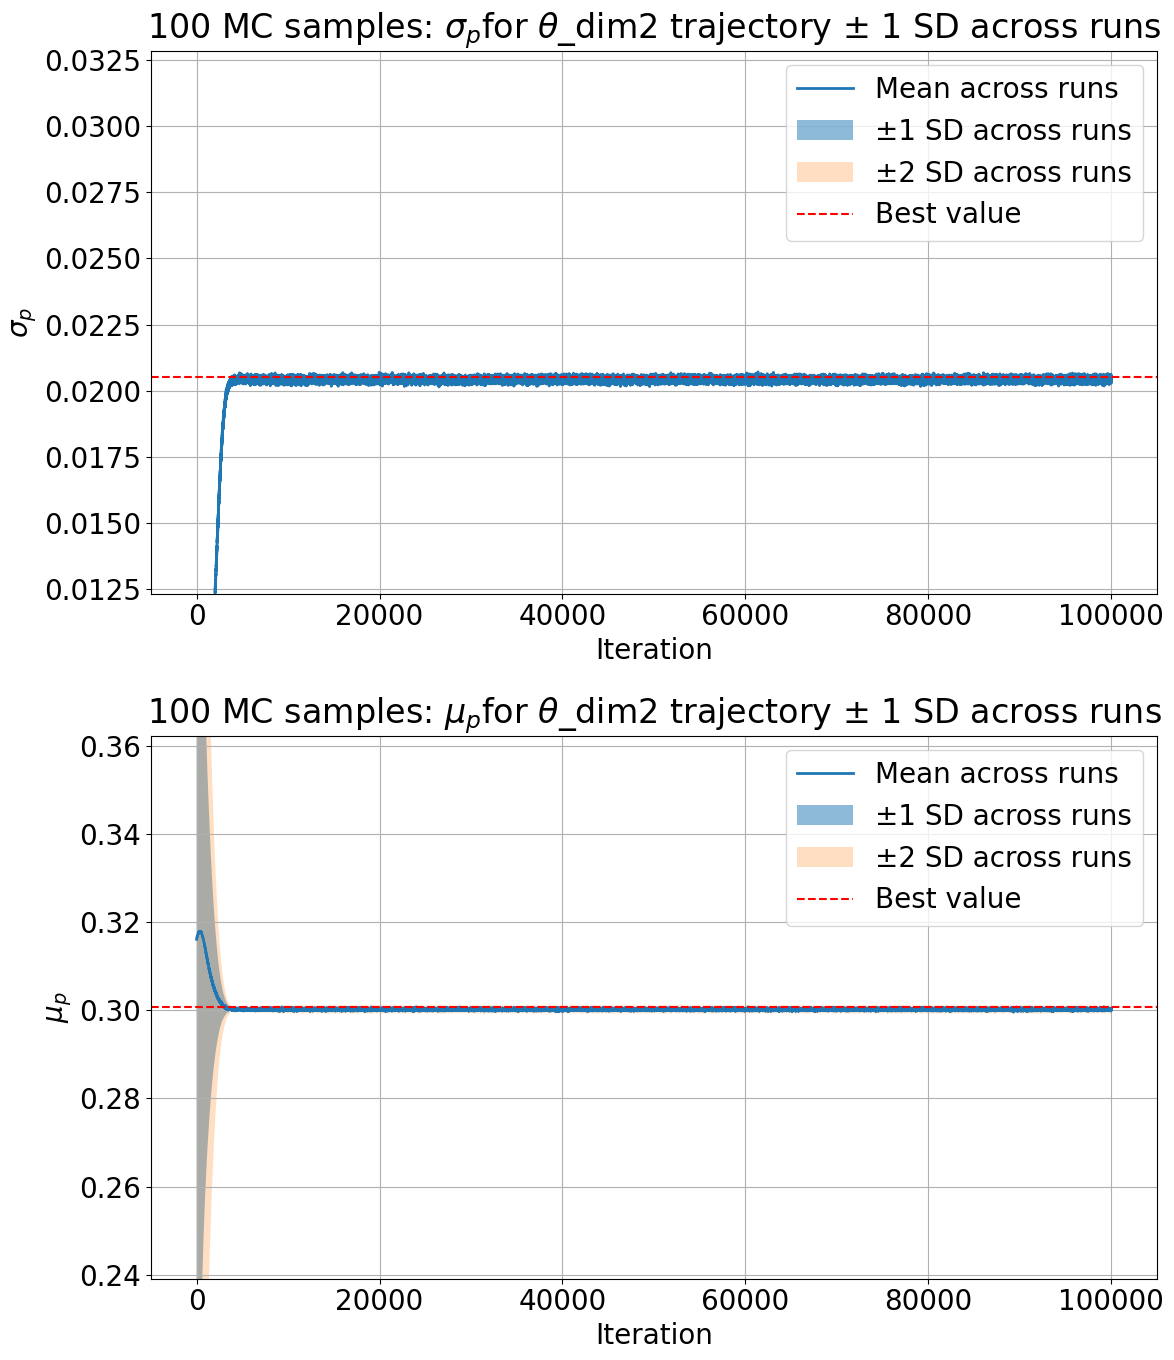

In [19]:
plot_simplex_dims(
    single_means,
    single_stds,
    multi_means,
    multi_stds,
    best_mean,
    best_cov,
    param_name=r"$\theta$",
    which_dims=list(range(n_cats)),
    k=min(3, n_restarts),
)


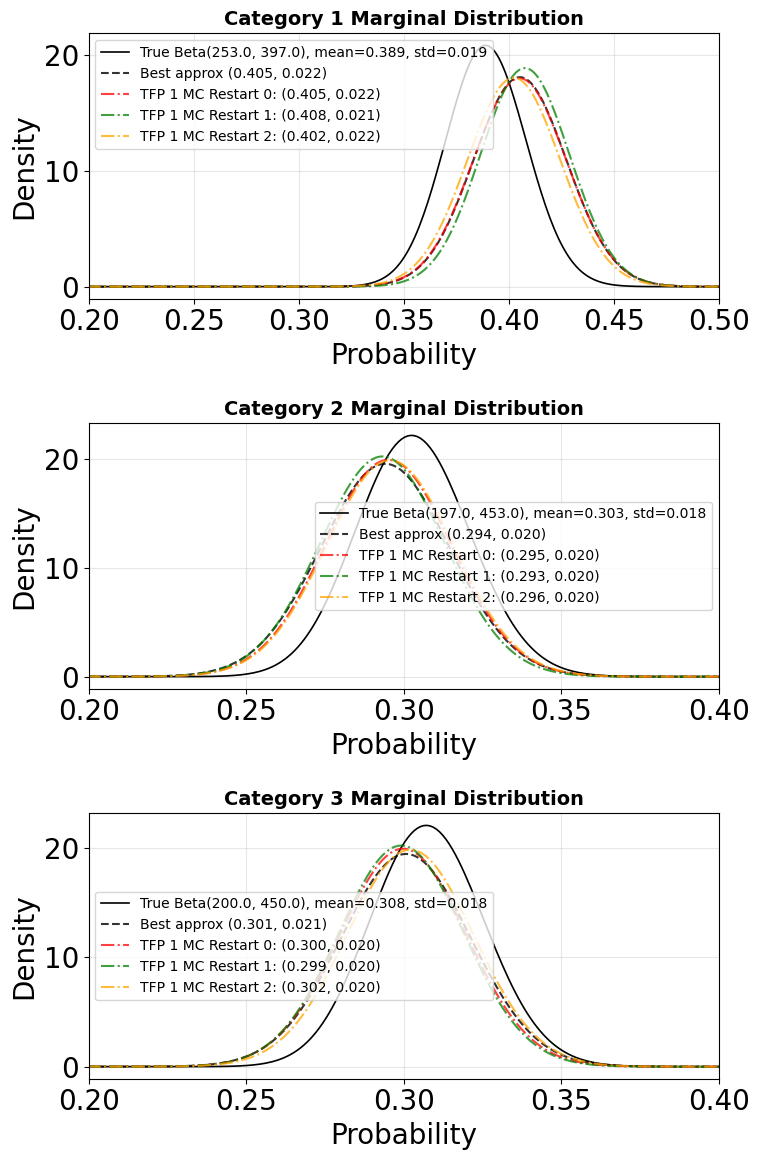

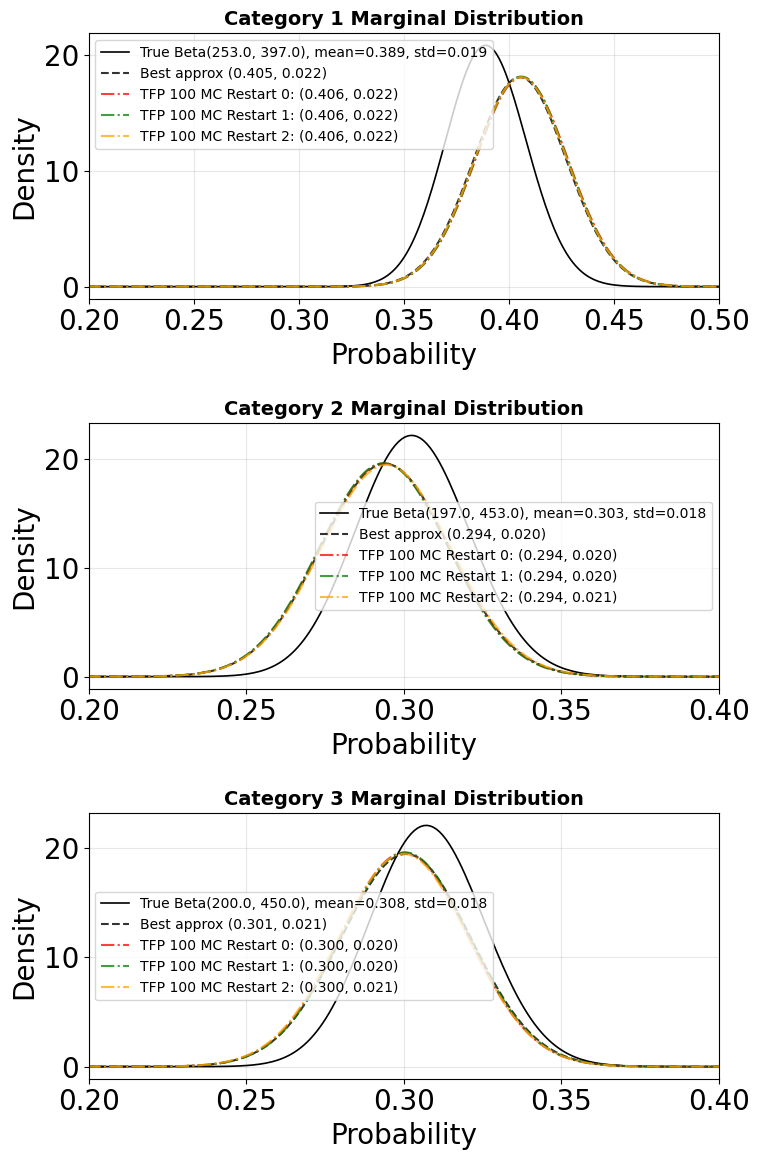

In [20]:
plot_dirichlet_marginals_few_restarts(
    single_means,
    single_stds,
    true_alpha_post=true_post["alpha_post"],
    true_mu_post=true_post["mean_post"],
    true_sigma_post=true_post["std_post"],
    best_mean=best_mean,
    best_cov=best_cov,
    which_restarts=list(range(min(3, n_restarts))),
    iteration=-1,
    label_prefix="TFP 1 MC ",
    lims = [(0.2, 0.5), (0.2, 0.4), (0.2, 0.4)]
)

plot_dirichlet_marginals_few_restarts(
    multi_means,
    multi_stds,
    true_alpha_post=true_post["alpha_post"],
    true_mu_post=true_post["mean_post"],
    true_sigma_post=true_post["std_post"],
    best_mean=best_mean,
    best_cov=best_cov,
    which_restarts=list(range(min(3, n_restarts))),
    iteration=-1,
    label_prefix="TFP 100 MC ",
    lims = [(0.2, 0.5), (0.2, 0.4), (0.2, 0.4)]
)


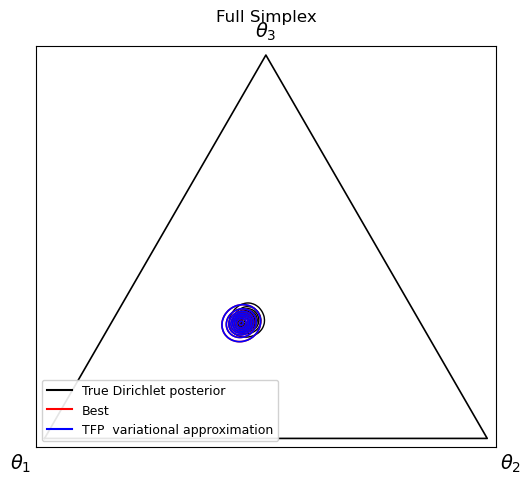

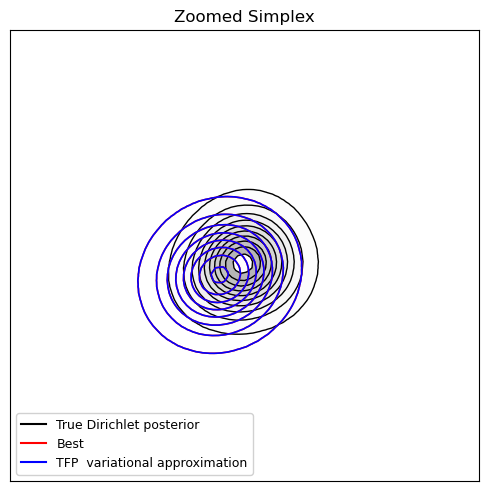

In [21]:
if n_cats == 3:
    plot_dirichlet_simplex_pdf_zoom(
        true_alpha_post=true_post["alpha_post"],
        best_mean=best_mean,
        best_cov=best_cov,
        overlay_mean=local_best["best_mean"],
        overlay_cov=local_best["best_cov"],
        framework_name="TFP ",
    )
